## Part 1 — Telematics data pipeline

Loads JSON telematic data into a Pandas DataFrame, converts the 'timestamp' column to datetime objects for time-series analysis, and outputs the dataset's structure and contents

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import folium
from folium.plugins import Fullscreen
import osmnx as ox
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

In [3]:
file_path = 'jego telematics mock dataset.json'

with open(file_path, 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data['records'])

df['timestamp'] = pd.to_datetime(df['timestamp'])

df.info()
display(df)

<class 'pandas.DataFrame'>
RangeIndex: 8643 entries, 0 to 8642
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   vehicle_id          8643 non-null   str                
 1   timestamp           8643 non-null   datetime64[us, UTC]
 2   latitude            8603 non-null   float64            
 3   longitude           8603 non-null   float64            
 4   speed_kmh           8643 non-null   float64            
 5   soc_pct             8643 non-null   float64            
 6   motor_current_amps  8643 non-null   float64            
 7   trip_id             5069 non-null   str                
 8   event               8643 non-null   str                
dtypes: datetime64[us, UTC](1), float64(5), str(3)
memory usage: 607.8 KB


,vehicle_id,timestamp,latitude,longitude,speed_kmh,soc_pct,motor_current_amps,trip_id,event
0,JEGO-V001,2026-05-14 04:30:00+00:00,6.428100,3.421900,0.0,96.96,1.34,NaN,overnight_idle
1,JEGO-V002,2026-05-14 04:30:00+00:00,6.455000,3.390000,0.0,91.55,1.24,NaN,overnight_idle
2,JEGO-V003,2026-05-14 04:30:00+00:00,6.500000,3.360000,0.0,93.98,0.98,NaN,overnight_idle
3,JEGO-V001,2026-05-14 04:30:30+00:00,6.428100,3.421900,0.0,96.96,1.56,NaN,overnight_idle
4,JEGO-V002,2026-05-14 04:30:30+00:00,6.455000,3.390000,0.0,91.55,1.78,NaN,overnight_idle
...,...,...,...,...,...,...,...,...,...
8638,JEGO-V002,2026-05-15 04:29:00+00:00,6.450994,3.402568,0.0,5.00,1.97,NaN,overnight_idle
8639,JEGO-V003,2026-05-15 04:29:00+00:00,6.512246,3.372270,0.0,5.00,2.33,NaN,overnight_idle
8640,JEGO-V001,2026-05-15 04:29:30+00:00,6.437864,3.439458,0.0,5.00,1.96,NaN,overnight_idle
8641,JEGO-V002,2026-05-15 04:29:30+00:00,6.450994,3.402568,0.0,5.00,1.75,NaN,overnight_idle


Group by 'vehicle_id' and 'timestamp' and remove duplicates (duplicate_ts events)

In [4]:
df_unique = df.drop_duplicates(subset=['vehicle_id', 'timestamp'])

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after dropping duplicates: {df_unique.shape}")

display(df_unique.head())

Original DataFrame shape: (8643, 9)
DataFrame shape after dropping duplicates: (8640, 9)


,vehicle_id,timestamp,latitude,longitude,speed_kmh,soc_pct,motor_current_amps,trip_id,event
0,JEGO-V001,2026-05-14 04:30:00+00:00,6.4281,3.4219,0.0,96.96,1.34,NaN,overnight_idle
1,JEGO-V002,2026-05-14 04:30:00+00:00,6.4550,3.3900,0.0,91.55,1.24,NaN,overnight_idle
2,JEGO-V003,2026-05-14 04:30:00+00:00,6.5000,3.3600,0.0,93.98,0.98,NaN,overnight_idle
3,JEGO-V001,2026-05-14 04:30:30+00:00,6.4281,3.4219,0.0,96.96,1.56,NaN,overnight_idle
4,JEGO-V002,2026-05-14 04:30:30+00:00,6.4550,3.3900,0.0,91.55,1.78,NaN,overnight_idle


Sorts the dataset chronologically per vehicle, removes invalid State of Charge (SoC) percentages, and handles 'soc_error' events by replacing them with linearly interpolated values.

In [5]:
df_cleaned = df_unique.sort_values(['vehicle_id', 'timestamp']).reset_index(drop=True)
print(f'Original df_cleaned size: {len(df_cleaned)}')

df_cleaned = df_cleaned.loc[(df_cleaned['soc_pct'] >= 0) & (df_cleaned['soc_pct'] <= 100)]
print(f'Size after removing out of ranged soc_pct values: {len(df_cleaned)}')

df_cleaned.loc[df_cleaned['event'] == 'soc_error', 'soc_pct'] = np.nan

df_cleaned['soc_pct'] = df_cleaned.groupby(['vehicle_id'])['soc_pct'].transform(lambda x: x.interpolate(method='linear'))

Original df_cleaned size: 8640
Size after removing out of ranged soc_pct values: 8640


Display rows with 'soc_error' events, before and after interpolation

In [6]:
soc_errors = df_unique[df_unique['event'] == 'soc_error']
display(soc_errors)

print('\n--- After Interpolation ---\n')

soc_cleaned_errors = df_cleaned[df_cleaned['event'] == 'soc_error']
display(soc_cleaned_errors)

,vehicle_id,timestamp,latitude,longitude,speed_kmh,soc_pct,motor_current_amps,trip_id,event
1774,JEGO-V003,2026-05-14 09:25:00+00:00,6.502788,3.361989,63.8,100.0,47.66,JEGO-V003-T05,soc_error
1967,JEGO-V001,2026-05-14 09:57:30+00:00,6.428506,3.432002,39.4,100.0,63.56,JEGO-V001-T05,soc_error
2146,JEGO-V002,2026-05-14 10:27:00+00:00,6.447586,3.399357,37.7,100.0,86.39,JEGO-V002-T06,soc_error



--- After Interpolation ---



,vehicle_id,timestamp,latitude,longitude,speed_kmh,soc_pct,motor_current_amps,trip_id,event
655,JEGO-V001,2026-05-14 09:57:30+00:00,6.428506,3.432002,39.4,5.0,63.56,JEGO-V001-T05,soc_error
3594,JEGO-V002,2026-05-14 10:27:00+00:00,6.447586,3.399357,37.7,5.0,86.39,JEGO-V002-T06,soc_error
6350,JEGO-V003,2026-05-14 09:25:00+00:00,6.502788,3.361989,63.8,5.0,47.66,JEGO-V003-T05,soc_error


**Interpolate GPS Gaps**: To maintain a continuous route for distance analysis

In [7]:
gps_gaps_count = df_cleaned[['latitude', 'longitude']].isnull().any(axis=1).sum()
print(f"Number of rows with GPS gaps (null lat/long): {gps_gaps_count}")

gps_gap_count = (df_cleaned['event'] == 'gps_gap').sum()
print(f"Number of rows with 'gps_gap' event: {gps_gap_count}")

df_interpolated = df_cleaned.sort_values(['vehicle_id', 'timestamp']).copy()
df_interpolated[['latitude', 'longitude']] = df_interpolated.groupby('vehicle_id')[['latitude', 'longitude']].transform(lambda x: x.interpolate(method='linear'))

display(df_interpolated.head())

Number of rows with GPS gaps (null lat/long): 40
Number of rows with 'gps_gap' event: 40


,vehicle_id,timestamp,latitude,longitude,speed_kmh,soc_pct,motor_current_amps,trip_id,event
0,JEGO-V001,2026-05-14 04:30:00+00:00,6.4281,3.4219,0.0,96.96,1.34,NaN,overnight_idle
1,JEGO-V001,2026-05-14 04:30:30+00:00,6.4281,3.4219,0.0,96.96,1.56,NaN,overnight_idle
2,JEGO-V001,2026-05-14 04:31:00+00:00,6.4281,3.4219,0.0,96.96,0.17,NaN,overnight_idle
3,JEGO-V001,2026-05-14 04:31:30+00:00,6.4281,3.4219,0.0,96.96,1.48,NaN,overnight_idle
4,JEGO-V001,2026-05-14 04:32:00+00:00,6.4281,3.4219,0.0,96.96,0.10,NaN,overnight_idle


In [8]:
df_timeline = df_interpolated.sort_values(by=['vehicle_id', 'timestamp']).reset_index(drop=True).copy()

# calculate continuous time difference (sampling time) - expected is 30s
df_timeline['time_diff_seconds'] = df_timeline.groupby('vehicle_id')['timestamp'].diff().dt.total_seconds().fillna(0)

display(df_timeline.head())

,vehicle_id,timestamp,latitude,longitude,speed_kmh,soc_pct,motor_current_amps,trip_id,event,time_diff_seconds
0,JEGO-V001,2026-05-14 04:30:00+00:00,6.4281,3.4219,0.0,96.96,1.34,NaN,overnight_idle,0.0
1,JEGO-V001,2026-05-14 04:30:30+00:00,6.4281,3.4219,0.0,96.96,1.56,NaN,overnight_idle,30.0
2,JEGO-V001,2026-05-14 04:31:00+00:00,6.4281,3.4219,0.0,96.96,0.17,NaN,overnight_idle,30.0
3,JEGO-V001,2026-05-14 04:31:30+00:00,6.4281,3.4219,0.0,96.96,1.48,NaN,overnight_idle,30.0
4,JEGO-V001,2026-05-14 04:32:00+00:00,6.4281,3.4219,0.0,96.96,0.10,NaN,overnight_idle,30.0


## Part 2 — Route mapping & geospatial analysis

Defining Log timeline

In [9]:
def haversine(lat1, lon1, lat2, lon2, radius=6371):
        """
        Compute haversine distance between two points,
        (long1, lat1) and (long2, lat2)
        """
    
        lat1_rad = np.radians(lat1)
        lon1_rad = np.radians(lon1)
        lat2_rad = np.radians(lat2)
        lon2_rad = np.radians(lon2)
    
        dlat = lat2_rad - lat1_rad
        dlon = lon2_rad - lon1_rad

        a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2

        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

        distance = radius * c
        return distance

In [11]:
# Calculate haversine distance
df_timeline['prev_lat'] = df_timeline.groupby('vehicle_id')['latitude'].shift(1)
df_timeline['prev_lon'] = df_timeline.groupby('vehicle_id')['longitude'].shift(1)

df_timeline['distance_km'] = df_timeline.apply(
    lambda row: haversine(row['prev_lat'], row['prev_lon'], row['latitude'], row['longitude']),
    axis=1
).fillna(0)
df_timeline.drop(columns=['prev_lat', 'prev_lon'], inplace=True)

# Calculate Distance (Speed * Time)
df_timeline['prev_speed_kmh'] = df_timeline.groupby('vehicle_id')['speed_kmh'].shift(1).fillna(0)
df_timeline['interval_avg_speed_kmh'] = (df_timeline['speed_kmh'] + df_timeline['prev_speed_kmh']) / 2
df_timeline['dist_from_speed_km'] = (df_timeline['interval_avg_speed_kmh'] / 3600) * df_timeline['time_diff_seconds']
df_timeline.drop(columns=['prev_speed_kmh', 'interval_avg_speed_kmh'], inplace=True)

display(df_timeline.head(200))

,vehicle_id,timestamp,latitude,longitude,speed_kmh,soc_pct,motor_current_amps,trip_id,event,time_diff_seconds,distance_km,dist_from_speed_km
0,JEGO-V001,2026-05-14 04:30:00+00:00,6.428100,3.421900,0.0,96.96,1.34,NaN,overnight_idle,0.0,0.000000,0.000000
1,JEGO-V001,2026-05-14 04:30:30+00:00,6.428100,3.421900,0.0,96.96,1.56,NaN,overnight_idle,30.0,0.000000,0.000000
2,JEGO-V001,2026-05-14 04:31:00+00:00,6.428100,3.421900,0.0,96.96,0.17,NaN,overnight_idle,30.0,0.000000,0.000000
3,JEGO-V001,2026-05-14 04:31:30+00:00,6.428100,3.421900,0.0,96.96,1.48,NaN,overnight_idle,30.0,0.000000,0.000000
4,JEGO-V001,2026-05-14 04:32:00+00:00,6.428100,3.421900,0.0,96.96,0.10,NaN,overnight_idle,30.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
195,JEGO-V001,2026-05-14 06:07:30+00:00,6.429300,3.422627,38.5,94.08,26.49,JEGO-V001-T01,regen_braking,30.0,0.022706,0.454167
196,JEGO-V001,2026-05-14 06:08:00+00:00,6.429591,3.422912,13.9,94.02,52.25,JEGO-V001-T01,regen_braking,30.0,0.045152,0.218333
197,JEGO-V001,2026-05-14 06:08:30+00:00,6.429773,3.422996,23.6,93.89,37.12,JEGO-V001-T01,trip,30.0,0.022264,0.156250
198,JEGO-V001,2026-05-14 06:09:00+00:00,6.429989,3.422809,49.5,93.66,85.05,JEGO-V001-T01,trip,30.0,0.031683,0.304583


In [12]:
lagos_bounds = {
    'lat_min': 6.35, 'lat_max': 6.70,
    'lon_min': 2.80, 'lon_max': 4.40
}
out_of_bounds = df_timeline[
    (df_timeline['latitude'] < lagos_bounds['lat_min']) |
    (df_timeline['latitude'] > lagos_bounds['lat_max']) |
    (df_timeline['longitude'] < lagos_bounds['lon_min']) |
    (df_timeline['longitude'] > lagos_bounds['lon_max'])
]
print(f"Records outside Lagos bounds: {len(out_of_bounds)}")

Records outside Lagos bounds: 0


Group by vehicle and trip, then sum the pre-calculated Haversine distances

In [14]:
trip_summary = df_timeline.groupby(['vehicle_id', 'trip_id']).agg(
    start_time=('timestamp', 'min'),
    end_time=('timestamp', 'max'),
    soc_pct_start=('soc_pct', 'first'),
    soc_pct_end=('soc_pct', 'last'),
    total_dist_km=('dist_from_speed_km', 'sum'),
    total_hav_dist_km=('distance_km', 'sum')
).reset_index()

vehicle_summary = trip_summary.groupby(['vehicle_id']).agg(
    start_time=('start_time', 'first'),
    end_time=('end_time', 'last'),
    soc_pct_start=('soc_pct_start', 'first'),
    soc_pct_end=('soc_pct_end', 'last'),
    total_dist_km=('total_dist_km', 'sum'),
    total_hav_dist_km=('total_hav_dist_km', 'sum')
).reset_index()

display(trip_summary.head())
display(vehicle_summary.head())

,vehicle_id,start_time,end_time,soc_pct_start,soc_pct_end,total_dist_km,total_hav_dist_km
0,JEGO-V001,2026-05-14 06:02:00+00:00,2026-05-14 21:59:30+00:00,96.70,5.0,606.451667,42.398874
1,JEGO-V002,2026-05-14 06:03:30+00:00,2026-05-14 21:59:30+00:00,91.41,5.0,613.402500,42.750920
2,JEGO-V003,2026-05-14 06:03:00+00:00,2026-05-14 21:59:30+00:00,93.87,5.0,613.617083,43.499951


In [18]:
display(trip_summary[['vehicle_id','trip_id', 'total_hav_dist_km']].head())

,vehicle_id,trip_id,total_hav_dist_km
0,JEGO-V001,JEGO-V001-T01,2.001045
1,JEGO-V001,JEGO-V001-T02,2.680368
2,JEGO-V001,JEGO-V001-T03,2.505375
3,JEGO-V001,JEGO-V001-T04,2.327962
4,JEGO-V001,JEGO-V001-T05,2.428358


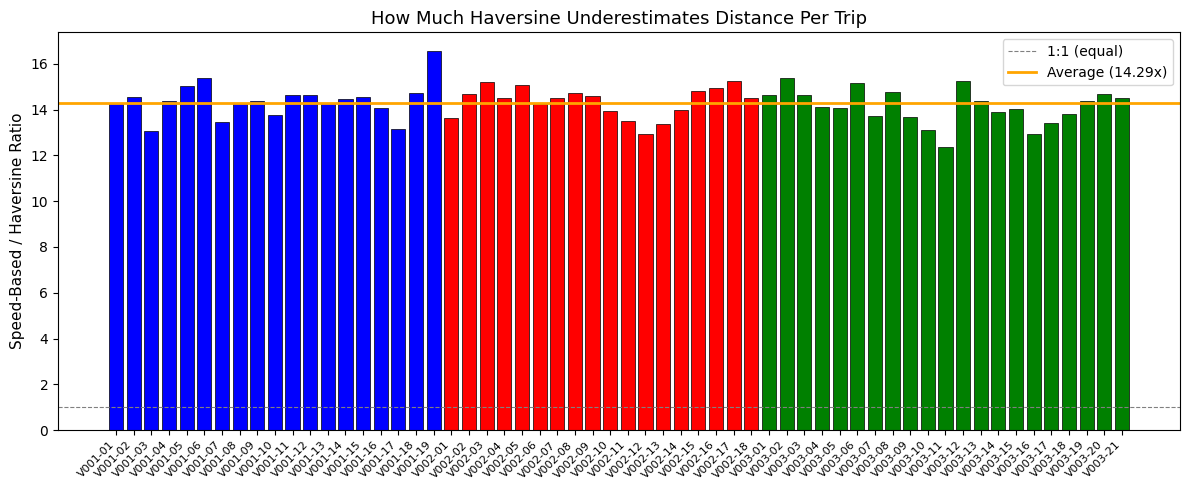

Average ratio across all trips: 14.3x
Min ratio: 12.4x
Max ratio: 16.5x

Total speed-based distance: 1833.47 km
Total Haversine distance:   128.65 km
Overall underestimation:    14.3x


In [43]:
# Compute ratio per trip
trip_comparison = trip_summary.copy()
trip_comparison['hav_speed_ratio'] = trip_comparison['total_dist_km'] / trip_comparison['total_hav_dist_km']

trip_comparison['vehicle'] = trip_comparison['vehicle_id'].str[-4:]
trip_comparison['trip_num'] = trip_comparison['trip_id'].str[-2:]

fig, ax = plt.subplots(figsize=(12, 5))
colors = {'V001': 'blue', 'V002': 'red', 'V003': 'green'}
bar_colors = trip_comparison['vehicle'].map(colors)

bars = ax.bar(
    range(len(trip_comparison)),
    trip_comparison['hav_speed_ratio'],
    color=bar_colors,
    edgecolor='black',
    linewidth=0.5
)

ax.set_xticks(range(len(trip_comparison)))
ax.set_xticklabels(
    [f"{v}-{t}" for v, t in zip(trip_comparison['vehicle'], trip_comparison['trip_num'])],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('Speed-Based / Haversine Ratio', fontsize=11)
ax.set_title('How Much Haversine Underestimates Distance Per Trip', fontsize=13)
ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, label='1:1 (equal)')

mean_ratio = trip_comparison['hav_speed_ratio'].mean()
ax.axhline(y=mean_ratio, color='orange', linestyle='-', linewidth=2, label=f'Average ({mean_ratio:.2f}x)')

ax.legend()
plt.tight_layout()
plt.show()

# Summary stats
print(f"Average ratio across all trips: {trip_comparison['hav_speed_ratio'].mean():.1f}x")
print(f"\nTotal speed-based distance: {trip_comparison['total_dist_km'].sum():.2f} km")
print(f"Total Haversine distance:   {trip_comparison['total_hav_dist_km'].sum():.2f} km")
print(f"Overall underestimation:    {(trip_comparison['total_dist_km'].sum() / trip_comparison['total_hav_dist_km'].sum()):.1f}x")

Raw GPS Plot

In [19]:
fleet_info = {
    'JEGO-V001': {'driver': 'Driver A', 'corridor': 'VI–Lekki', 'color': 'blue'},
    'JEGO-V002': {'driver': 'Driver B', 'corridor': 'Lagos Island–Mainland', 'color': 'red'},
    'JEGO-V003': {'driver': 'Driver C', 'corridor': 'Surulere–Ikeja', 'color': 'green'}
}

In [20]:
m = folium.Map(location=[6.5244, 3.3792], zoom_start=11, tiles='OpenStreetMap')
Fullscreen().add_to(m)

for vid, info in fleet_info.items():
    v_data = df_timeline[(df_timeline['vehicle_id'] == vid) & (df_timeline['event'] == 'trip')]

    # Create a layer for this vehicle
    group = folium.FeatureGroup(name=f"{vid} ({info['driver']})")

    # Plot each individual trip
    for tid, t_df in v_data.groupby('trip_id'):
        points_lat_lon = t_df[['latitude', 'longitude']].values.tolist()

        if len(points_lat_lon) > 1:
            points_lon_lat = [[lon, lat] for lat, lon in points_lat_lon]

            trip_feature = {
                "type": "Feature",
                "geometry": {
                    "type": "LineString",
                    "coordinates": points_lon_lat
                },
                "properties": {
                    "vehicle": vid,
                    "trip": tid,
                    "corridor": info['corridor'],
                    "color": info['color']
                }
            }

            # Add interactive GeoJson layer
            folium.GeoJson(
                trip_feature,
                style_function=lambda feature: {
                    'color': feature['properties']['color'],
                    'weight': 3,
                    'opacity': 0.5
                },
                highlight_function=lambda feature: {
                    'color': 'black',  
                    'weight': 4,       
                    'opacity': 1.0 
                },
                tooltip=folium.GeoJsonTooltip(
                    fields=['vehicle', 'trip', 'corridor'],
                    aliases=['Vehicle:', 'Trip:', 'Corridor:']
                )
            ).add_to(group)

            folium.CircleMarker(points_lat_lon[0], radius=4, color='white', fill=True, fill_color='green', fill_opacity=1).add_to(group)
            folium.CircleMarker(points_lat_lon[-1], radius=4, color='white', fill=True, fill_color='red', fill_opacity=1).add_to(group)

    group.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# Display the map
m.save("jego_fleet_corridors_raw.html")

In [23]:
assert df[df['speed_kmh'] > 80].empty, "Data validation failed: Found records with speed > 80 km/h"

Optimized map, by snapping waypoints to real road tracks using OSMnx Map Matching

In [44]:
df_map_clean = df_timeline[df_timeline['event'] != 'gps_error'].copy()

print("Downloading Lagos OSM road network...")
G = ox.graph_from_place('Lagos, Nigeria', network_type='drive')
print("Graph downloaded!")

m = folium.Map(location=[6.5244, 3.3792], zoom_start=11, tiles='OpenStreetMap')
Fullscreen().add_to(m)

for vid, info in fleet_info.items():
    v_data = df_map_clean[(df_map_clean['vehicle_id'] == vid) & (df_map_clean['event'] == 'trip')]
    group = folium.FeatureGroup(name=f"{vid} ({info['driver']})")

    for tid, t_df in v_data.groupby('trip_id'):
        lats = t_df['latitude'].tolist()
        lons = t_df['longitude'].tolist()

        if len(lats) > 1:
            nearest_nodes = ox.distance.nearest_nodes(G, X=lons, Y=lats)
            route_nodes = []
            
            for i in range(len(nearest_nodes) - 1):
                start_node = nearest_nodes[i]
                end_node = nearest_nodes[i+1]
                
                if start_node == end_node:
                    continue
                    
                try:
                    path = ox.routing.shortest_path(G, start_node, end_node, weight='length')
                    route_nodes.extend(path[:-1])
                except nx.NetworkXNoPath:
                    continue
            
            if len(nearest_nodes) > 0:
                route_nodes.append(nearest_nodes[-1])

            if len(route_nodes) > 1:
                snapped_points_lon_lat = [[G.nodes[node]['x'], G.nodes[node]['y']] for node in route_nodes]
                
                trip_feature = {
                    "type": "Feature",
                    "geometry": {
                        "type": "LineString",
                        "coordinates": snapped_points_lon_lat
                    },
                    "properties": {
                        "vehicle": vid,
                        "trip": tid,
                        "corridor": info['corridor'],
                        "color": info['color']
                    }
                }

                folium.GeoJson(
                    trip_feature,
                    style_function=lambda feature: {
                        'color': feature['properties']['color'],
                        'weight': 4,
                        'opacity': 0.8
                    },
                    highlight_function=lambda feature: {
                        'color': 'black',  
                        'weight': 4,       
                        'opacity': 1.0     
                    },
                    tooltip=folium.GeoJsonTooltip(
                        fields=['vehicle', 'trip', 'corridor'],
                        aliases=['Vehicle:', 'Trip:', 'Corridor:']
                    )
                ).add_to(group)

            folium.CircleMarker([lats[0], lons[0]], radius=4, color='white', fill=True, fill_color='green', fill_opacity=1).add_to(group)
            folium.CircleMarker([lats[-1], lons[-1]], radius=4, color='white', fill=True, fill_color='red', fill_opacity=1).add_to(group)

    group.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m.save("jego_fleet_corridors_snapped.html")

Graph downloaded!


## Part 3 — Carbon displacement calculation

In [26]:
constants = data.get('constants', {})

BATTERY_CAPACITY_KWH  = constants.get('pack_capacity_kwh')
GRID_EMISSION_FACTOR = constants.get('grid_emission_factor_kg_co2_per_kwh')
ICE_EMISSION_FACTOR = constants.get('ice_baseline_kg_co2_per_km')

df_timeline['prev_soc'] = df_timeline.groupby('vehicle_id')['soc_pct'].shift(1)

df_timeline['soc_delta_percent'] = df_timeline['prev_soc'] - df_timeline['soc_pct']

# Convert percentage change into actual kWh
df_timeline['energy_kwh'] = (df_timeline['soc_delta_percent'] / 100) * BATTERY_CAPACITY_KWH
df_timeline['energy_kwh'] = df_timeline['energy_kwh'].fillna(0)

# Aggregate Base Metrics per Vehicle
summary_cards = df_timeline.groupby('vehicle_id').agg(
    total_km_driven=('dist_from_speed_km', 'sum'),
    total_kwh_consumed=('energy_kwh', 'sum')
).reset_index()

# Calculate Emissions & Displaced Carbon
summary_cards['ice_emissions_kg'] = summary_cards['total_km_driven'] * ICE_EMISSION_FACTOR
summary_cards['ev_emissions_kg'] = summary_cards['total_kwh_consumed'] * GRID_EMISSION_FACTOR

summary_cards['net_co2_displaced_kg'] = summary_cards['ice_emissions_kg'] - summary_cards['ev_emissions_kg']

# Calculate Fleet Efficiency
summary_cards['efficiency_km_per_kwh'] = summary_cards['total_km_driven'] / summary_cards['total_kwh_consumed']

# Calculate the average efficiency across all 3 vehicles
fleet_avg_efficiency = summary_cards['efficiency_km_per_kwh'].mean()

summary_cards['efficiency_score_vs_fleet_%'] = (summary_cards['efficiency_km_per_kwh'] / fleet_avg_efficiency) * 100

summary_cards = summary_cards.round({
    'total_km_driven': 2,
    'total_kwh_consumed': 2,
    'ev_emissions_kg':2,
    'ice_emissions_kg':2,
    'net_co2_displaced_kg': 2,
    'efficiency_km_per_kwh': 2,
    'efficiency_score_vs_fleet_%': 1
})

zero_carbon_summary = summary_cards[[
    'vehicle_id',
    'total_km_driven',
    'total_kwh_consumed',
    'ev_emissions_kg',
    'ice_emissions_kg',
    'net_co2_displaced_kg',
    'efficiency_score_vs_fleet_%'
]]

# display(summary_cards)
display(zero_carbon_summary)

,vehicle_id,total_km_driven,total_kwh_consumed,ev_emissions_kg,ice_emissions_kg,net_co2_displaced_kg,efficiency_score_vs_fleet_%
0,JEGO-V001,609.92,24.37,10.48,117.10,106.63,96.1
1,JEGO-V002,617.12,22.94,9.86,118.49,108.63,103.3
2,JEGO-V003,617.73,23.58,10.14,118.60,108.47,100.6


In [27]:
regen_mask = df_timeline['energy_kwh'] < 0
regen_summary = df_timeline[regen_mask].groupby('vehicle_id')['energy_kwh'].agg(['sum', 'count']).reset_index()
regen_summary.columns = ['vehicle_id', 'total_regen_kwh', 'regen_events']
regen_summary['total_regen_kwh'] = regen_summary['total_regen_kwh'].abs()

display(regen_summary)

,vehicle_id,total_regen_kwh,regen_events


## Part 4 — Anomaly detection & predictive alert

In [40]:
def detect_motor_anomalies(df):
    driving_events = ['trip']
    df_driving = df[df['event'].isin(driving_events)].copy()
    
    if df_driving.empty:
        return pd.DataFrame()
    
    # Feature engineering 
    df_driving['current_speed_ratio'] = df_driving['motor_current_amps'] / (df_driving['speed_kmh']+0.001)
    
    features = ['motor_current_amps', 'current_speed_ratio', 'soc_pct']
    X = df_driving[features].fillna(0)
    
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
    
    model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
    model.fit(X_train)
    
    train_anomaly_rate = (model.predict(X_train) == -1).mean()
    test_anomaly_rate = (model.predict(X_test) == -1).mean()
    
    print(f"--- Model Validation ---")
    print(f"Train Anomaly Rate: {train_anomaly_rate:.2%}")
    print(f"Test Anomaly Rate:  {test_anomaly_rate:.2%}")
    print(f"--------------------\n")
    
    # Use the trained model to score all driving events
    df_driving['anomaly_score'] = model.predict(X)
    
    anomalies = df_driving[df_driving['anomaly_score'] == -1].copy()
    
    return anomalies

anomalies_df = detect_motor_anomalies(df_timeline).reset_index(drop=True)
display(anomalies_df.tail())

--- Model Validation ---
Train Anomaly Rate: 1.00%
Test Anomaly Rate:  1.71%
--------------------



,vehicle_id,timestamp,latitude,longitude,speed_kmh,soc_pct,motor_current_amps,trip_id,event,time_diff_seconds,distance_km,dist_from_speed_km,prev_soc,soc_delta_percent,energy_kwh,current_speed_ratio,anomaly_score
35,JEGO-V003,2026-05-14 09:17:00+00:00,6.502302,3.361845,12.3,5.64,90.74,JEGO-V003-T05,trip,30.0,0.031360,0.150000,5.72,0.08,0.0212,7.376636,-1
36,JEGO-V003,2026-05-14 14:56:00+00:00,6.507591,3.367953,12.4,5.00,87.58,JEGO-V003-T13,trip,30.0,0.012997,0.125417,5.00,0.00,0.0000,7.062334,-1
37,JEGO-V003,2026-05-14 17:00:30+00:00,6.512767,3.367778,67.8,5.00,166.38,JEGO-V003-T16,trip,30.0,0.024290,0.372083,5.00,0.00,0.0000,2.453946,-1
38,JEGO-V003,2026-05-14 17:01:30+00:00,6.512524,3.367942,26.7,5.00,179.38,JEGO-V003-T16,trip,30.0,0.012079,0.177917,5.00,0.00,0.0000,6.718100,-1
39,JEGO-V003,2026-05-14 17:26:30+00:00,6.513817,3.369096,12.3,5.00,91.56,JEGO-V003-T16,trip,30.0,0.027379,0.137083,5.00,0.00,0.0000,7.443297,-1


In [32]:
def generate_dashboard_alerts(anomalies_df):
    """
    Generates professional, data-driven dashboard alerts by injecting 
    real-time telemetry values into actionable templates.
    """
    alert_records = []

    templates = {
        "high_load": (
            "High Mechanical Load | Unusual current draw of {current}A detected "
            "at {speed} km/h. | Inspect drivetrain and motor for resistance."
        ),
        "battery_drain": (
            "Rapid Battery Drain | SoC dropped significantly while drawing {current}A. "
            "Current SoC: {soc}%. | Check battery health and charging connections."
        ),
        "default": (
            "Energy Pattern Anomaly | Unusual consumption detected ({current}A). "
            "| Monitor vehicle performance during next shift."
        )
    }

    # Compute percentile thresholds from the anomalous data
    ratio_90th = anomalies_df['current_speed_ratio'].quantile(0.90)
    current_90th = anomalies_df['motor_current_amps'].quantile(0.90)

    for _, row in anomalies_df.iterrows():
        current = round(row['motor_current_amps'], 1)
        speed = round(row['speed_kmh'], 1)
        ratio = round(row['current_speed_ratio'], 2)
        soc = row['soc_pct']
        
        if ratio >= ratio_90th:
            alert_type = "high_load"
        elif current >= current_90th:
            alert_type = "battery_drain"
        else:
            alert_type = "default"

        message = templates[alert_type].format(
            current=current, speed=speed, soc=soc
        )

        alert_records.append({
            "vehicle_id": row['vehicle_id'],
            "timestamp": row['timestamp'],
            "alert_type": alert_type,
            "dashboard_alert": message
        })

    return pd.DataFrame(alert_records)

alerts_df = generate_dashboard_alerts(anomalies_df)
display(alerts_df)

,vehicle_id,timestamp,alert_type,dashboard_alert
0,JEGO-V001,2026-05-14 06:19:00+00:00,default,Energy Pattern Anomaly | Unusual consumption d...
1,JEGO-V001,2026-05-14 06:24:30+00:00,default,Energy Pattern Anomaly | Unusual consumption d...
2,JEGO-V001,2026-05-14 07:03:30+00:00,default,Energy Pattern Anomaly | Unusual consumption d...
3,JEGO-V001,2026-05-14 07:11:00+00:00,default,Energy Pattern Anomaly | Unusual consumption d...
4,JEGO-V001,2026-05-14 07:15:30+00:00,default,Energy Pattern Anomaly | Unusual consumption d...
5,JEGO-V001,2026-05-14 08:33:00+00:00,default,Energy Pattern Anomaly | Unusual consumption d...
6,JEGO-V001,2026-05-14 08:55:30+00:00,default,Energy Pattern Anomaly | Unusual consumption d...
7,JEGO-V001,2026-05-14 08:56:30+00:00,battery_drain,Rapid Battery Drain | SoC dropped significantl...
8,JEGO-V001,2026-05-14 08:57:30+00:00,battery_drain,Rapid Battery Drain | SoC dropped significantl...
9,JEGO-V001,2026-05-14 08:58:00+00:00,default,Energy Pattern Anomaly | Unusual consumption d...


In [42]:
import pandas as pd

def generate_interactive_html_dashboard(anomalies_df, output_filename="jego_operator_dashboard.html"):
    """
    Generates a standalone, interactive HTML dashboard using only pure Python and Vanilla JS/CSS.
    Emojis removed, and Javascript filtering logic updated for cross-browser reliability.
    """
    
    templates = {
        "high_load": {
            "title": "High Mechanical Load",
            "details": "Unusual current draw of {current}A detected at {speed} km/h.",
            "action": "Inspect drivetrain and motor for resistance.",
            "color": "#e74c3c" # Red
        },
        "battery_drain": {
            "title": "Rapid Battery Drain",
            "details": "SoC dropped significantly while drawing {current}A. Current SoC: {soc}%.",
            "action": "Check battery health and charging connections.",
            "color": "#f39c12" # Orange
        },
        "default": {
            "title": "Energy Pattern Anomaly",
            "details": "Unusual consumption detected ({current}A).",
            "action": "Monitor vehicle performance during next shift.",
            "color": "#3498db" # Blue
        }
    }

    cards_html = ""
    for _, row in anomalies_df.iterrows():
        current = round(row['motor_current_amps'], 1)
        speed = round(row['speed_kmh'], 1)
        ratio = round(row['current_speed_ratio'], 2)
        soc = row['soc_pct']
        vid = str(row['vehicle_id']).strip() # Ensure clean strings for JS filtering
        time = row['timestamp']
        
        if ratio >= ratio_90th:
            alert_type = "high_load"
        elif current >= current_90th:
            alert_type = "battery_drain"
        else:
            alert_type = "default"

        t = templates[alert_type]
        details = t['details'].format(current=current, speed=speed, soc=soc)
        
        cards_html += f"""
        <div class="card" data-type="{alert_type}" data-vehicle="{vid}">
            <div class="card-header" style="border-bottom: 2px solid {t['color']}">
                <div class="card-title" style="color: {t['color']}">{t['title']}</div>
                <div class="card-meta">{vid} &bull; {time}</div>
            </div>
            <div class="card-body">
                <p>{details}</p>
                <div class="action-box"><b>Action Required:</b> {t['action']}</div>
                <div class="telemetry-badges">
                    <span><b>Current:</b> {current}A</span>
                    <span><b>Speed:</b> {speed} km/h</span>
                    <span><b>SoC:</b> {soc}%</span>
                </div>
            </div>
        </div>
        """

    # Extract unique vehicles for the dropdown
    unique_vehicles = anomalies_df['vehicle_id'].unique()
    vehicle_options = "".join([f'<option value="{str(v).strip()}">{v}</option>' for v in unique_vehicles])

    html_content = f"""
    <!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>JéGO X Fleet Monitoring</title>
        <style>
            body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif; background-color: #121212; color: #e0e0e0; padding: 20px; }}
            .container {{ max-width: 900px; margin: 0 auto; }}
            .header {{ border-bottom: 1px solid #333; padding-bottom: 20px; margin-bottom: 20px; }}
            .controls {{ display: flex; gap: 15px; margin-bottom: 20px; background: #1e1e1e; padding: 15px; border-radius: 8px; }}
            select {{ padding: 8px; background: #2d2d2d; color: white; border: 1px solid #444; border-radius: 4px; outline: none; cursor: pointer; }}
            .card {{ background-color: #1e1e1e; border-radius: 8px; margin-bottom: 16px; padding: 16px; box-shadow: 0 4px 6px rgba(0,0,0,0.3); }}
            .card-header {{ display: flex; justify-content: space-between; align-items: center; padding-bottom: 10px; margin-bottom: 10px; }}
            .card-title {{ font-size: 18px; font-weight: bold; margin: 0; }}
            .card-meta {{ font-size: 13px; color: #aaa; }}
            .action-box {{ background-color: #2d2d2d; border: 1px solid #444; padding: 10px; border-radius: 6px; color: #ffeb3b; margin: 10px 0; font-size: 14px; }}
            .telemetry-badges {{ display: flex; gap: 15px; font-size: 12px; color: #bbb; margin-top: 10px; }}
        </style>
    </head>
    <body>
        <div class="container">
            <div class="header">
                <h1 style="margin:0; color: white;">JéGO X Operator Dashboard</h1>
                <p style="color: #aaa; margin-top:5px;">Live maintenance alerts and anomaly detection.</p>
            </div>
            
            <div class="controls">
                <select id="typeFilter" onchange="filterCards()">
                    <option value="all">All Alert Types</option>
                    <option value="high_load">High Mechanical Load</option>
                    <option value="battery_drain">Rapid Battery Drain</option>
                    <option value="default">Energy Pattern Anomaly</option>
                </select>
                
                <select id="vehicleFilter" onchange="filterCards()">
                    <option value="all">All Vehicles</option>
                    {vehicle_options}
                </select>
            </div>

            <div id="alertsContainer">
                {cards_html}
            </div>
        </div>

        <script>
            // Bulletproof Javascript filtering
            function filterCards() {{
                const typeFilter = document.getElementById('typeFilter').value;
                const vehicleFilter = document.getElementById('vehicleFilter').value;
                const cards = document.querySelectorAll('.card');

                cards.forEach(card => {{
                    const cardType = card.getAttribute('data-type');
                    const cardVehicle = card.getAttribute('data-vehicle');
                    
                    const typeMatches = (typeFilter === 'all' || cardType === typeFilter);
                    const vehicleMatches = (vehicleFilter === 'all' || cardVehicle === vehicleFilter);

                    // Use inline display styling instead of CSS classes for reliable hiding/showing
                    if (typeMatches && vehicleMatches) {{
                        card.style.display = 'block';
                    }} else {{
                        card.style.display = 'none';
                    }}
                }});
            }}
        </script>
    </body>
    </html>
    """
    
    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(html_content)
    
    print(f"Dashboard successfully generated: {output_filename}")

generate_interactive_html_dashboard(anomalies_df)

✅ Dashboard successfully generated: jego_operator_dashboard.html


In [38]:
print("=== Anomaly Counts ===")
print(alerts_df['alert_type'].value_counts())

print("\n=== Anomalies by Vehicle ===")
display(alerts_df.groupby(['vehicle_id', 'alert_type']).size().unstack(fill_value=0))

=== Anomaly Counts ===
alert_type
default          32
battery_drain     4
high_load         4
Name: count, dtype: int64

=== Anomalies by Vehicle ===


alert_type,battery_drain,default,high_load
vehicle_id,,,
JEGO-V001,3,10,1
JEGO-V002,0,16,1
JEGO-V003,1,6,2
